
# Supply Chain Delivery Delay Prediction and Logistics Optimization
**name** Taqwa Almohammedi

**Course:** DSAI4103 Business Analytics  
**Dataset:** DataCo Smart Supply Chain Dataset (Kaggle)

## Project Overview
In modern supply chains, delivery delays can cause major financial losses and customer dissatisfaction. 
The goal of this project is to analyze supply chain data, identify patterns behind delayed deliveries, 
and build a machine learning model to predict the likelihood of late deliveries and support logistics optimization.

This notebook follows a complete **Business Analytics pipeline**:

1. Import Libraries
2. Load Dataset 
3. Dataset Overview 
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Define Features and Target
8. Machine Learning Model
9. Confusion Matrix Visualization  
6. Model explainability using SHAP
7. Bias and fairness analysis
8. Key business insights


The final insights will be visualized in a **Power BI dashboard**.

This project aims to support data-driven decision-making in supply chain operations by improving delivery performance and reducing delays.


In [1]:
#!pip install shap


In [2]:
#!pip install --upgrade numpy pandas



# 1. Import Libraries
The following libraries are used for data analysis, visualization, and machine learning model development.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap



# 2. Load Dataset
The dataset contains information about orders, products, customers, and shipping operations.
We load the dataset into a pandas DataFrame for analysis.


In [4]:
df = pd.read_csv("archive/DataCoSupplyChainDataset.csv", encoding="latin1")

df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



# 3. Dataset Overview
Before analyzing the data, we first explore the structure of the dataset.

We want to understand:
- Number of rows and columns
- Column data types
- Missing values


In [5]:
df.shape

(180519, 53)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [7]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


The dataset contains multiple features related to orders, customers, products, and shipping operations. It includes both numerical and categorical variables, which will require preprocessing before model development.


# 4. Data Cleaning
Real-world datasets often contain missing values, duplicate records, or irrelevant columns.
We clean the data to improve model performance.


In [8]:
# Check missing values
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [9]:
df = df.drop(columns=[
    "Order Id",
    "Customer Id",
    "Order Customer Id",
    "Order Item Id",
    "Delivery Status",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Order Status",
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Product Description",
    "Order Zipcode",          
    "Customer Zipcode"       
], errors='ignore')

### Remove Irrelevant and Leakage Columns

Some columns contain sensitive information or directly reveal the delivery outcome.
These columns are removed to prevent data leakage and improve model reliability.

The zipcode-related columns were removed due to a high number of missing values and limited predictive usefulness, which could negatively impact model performance.

In [10]:
# Remove duplicates
df = df.drop_duplicates()

df.shape


(180519, 38)

The dataset initially contained 53 features. After removing irrelevant, redundant, and leakage-related columns, the number of features was reduced to 38. The number of records remained unchanged, ensuring no loss of data. This cleaning step improves model efficiency and reliability.

In [11]:
df.isnull().sum()

Type                          0
Benefit per order             0
Sales per customer            0
Late_delivery_risk            0
Category Id                   0
Category Name                 0
Customer City                 0
Customer Country              0
Customer Segment              0
Customer State                0
Customer Street               0
Department Id                 0
Department Name               0
Latitude                      0
Longitude                     0
Market                        0
Order City                    0
Order Country                 0
order date (DateOrders)       0
Order Item Cardprod Id        0
Order Item Discount           0
Order Item Discount Rate      0
Order Item Product Price      0
Order Item Profit Ratio       0
Order Item Quantity           0
Sales                         0
Order Item Total              0
Order Profit Per Order        0
Order Region                  0
Order State                   0
Product Card Id               0
Product 

Missing values were identified using df.isnull().sum(). Columns with a high number of missing values, such as zipcode-related features, were removed. Remaining missing values were minimal and handled appropriately to ensure data quality.


# 5. Exploratory Data Analysis (EDA)
EDA helps us understand patterns and relationships within the dataset.

We explore:
- Distribution of late deliveries
- Sales trends
- Shipping methods
- Regional performance


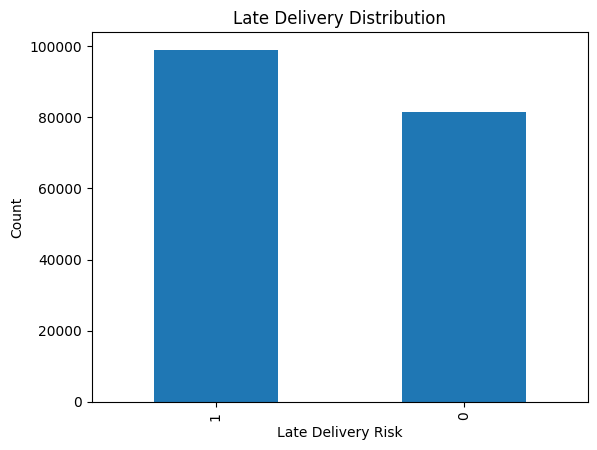

In [12]:
# Distribution of late delivery risk
df['Late_delivery_risk'].value_counts().plot(kind='bar')
plt.title("Late Delivery Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Count")
plt.show()


The distribution shows that the number of on-time deliveries is slightly higher than late deliveries. However, there is still a significant portion of delayed orders, indicating the importance of predicting delivery risk.

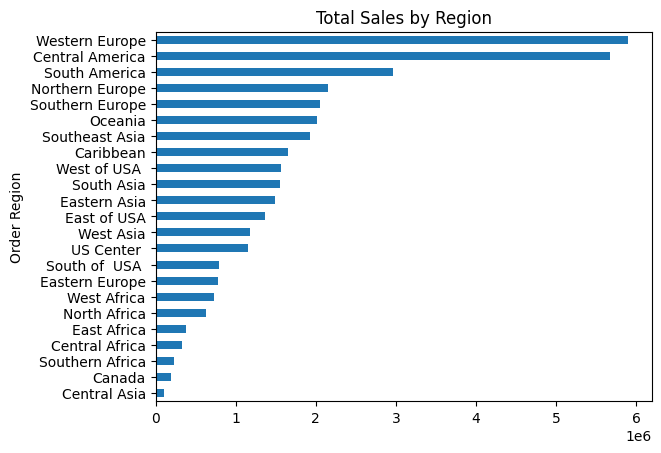

In [13]:
# Sales by region
df.groupby("Order Region")["Sales"].sum().sort_values().plot(kind='barh')
plt.title("Total Sales by Region")
plt.show()


Sales are highest in Western Europe and Central America, indicating these regions are key markets. Regions with lower sales may require strategic improvements in logistics and distribution.

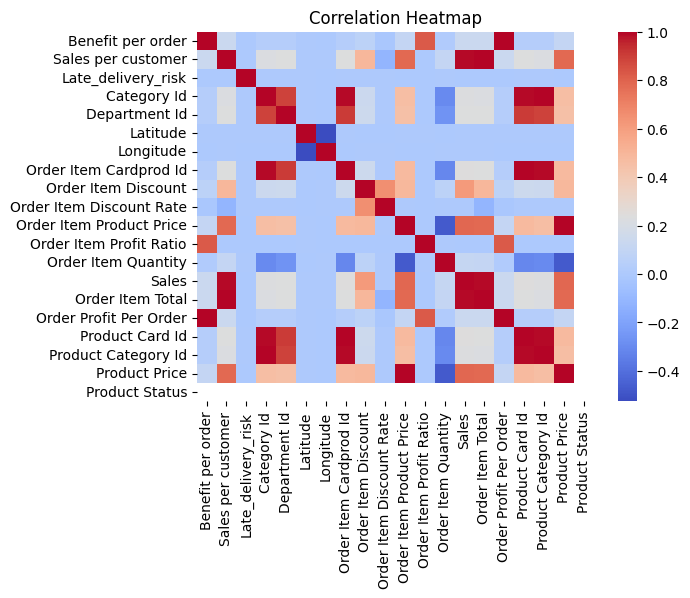

In [14]:
# Correlation heatmap for numerical features
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap shows relationships between numerical features. Some features, such as sales and order item total, show strong positive correlation, while most features have weak correlation with the target variable, indicating the need for machine learning models to capture complex patterns.

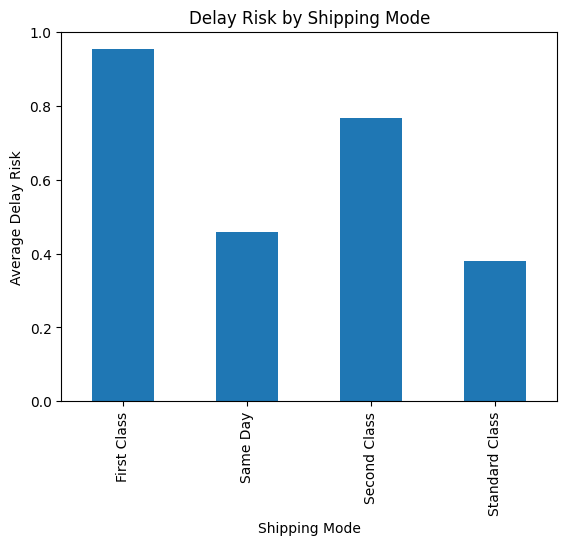

In [15]:
#Shipping Mode vs Delay
df.groupby('Shipping Mode')['Late_delivery_risk'].mean().plot(kind='bar')
plt.title("Delay Risk by Shipping Mode")
plt.ylabel("Average Delay Risk")
plt.show()

The analysis shows that First Class and Second Class shipping modes have higher delay risk compared to Standard Class and Same Day delivery. This may indicate operational challenges or higher demand associated with premium shipping options. Interestingly, faster shipping does not always guarantee lower delay risk, highlighting the complexity of supply chain logistics.

This insight can help businesses prioritize improvements in high-risk shipping categories to reduce delays and improve customer satisfaction.


# 6. Feature Engineering
Feature engineering helps improve model performance by turning raw data into more useful features.

In this step, we extract information from date columns to capture patterns over time. We also convert categorical (text) variables into numerical values so that the machine learning model can process them.

In [16]:
# Encode categorical variables
# Convert text columns into numbers so the model can use them

from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))


# 7. Define Features and Target
Our goal is to predict whether a shipment will be delayed.

Target variable:
**Late_delivery_risk**


In [17]:
X = df.drop("Late_delivery_risk", axis=1)
y = df["Late_delivery_risk"]


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



# 8. Machine Learning Model
i train a Random Forest Classifier to predict delivery delay risk. Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting, making it well-suited for structured datasets.

In [19]:
model = RandomForestClassifier()
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))


Accuracy: 0.8073343673831155
              precision    recall  f1-score   support

           0       0.74      0.88      0.80     16307
           1       0.88      0.75      0.81     19797

    accuracy                           0.81     36104
   macro avg       0.81      0.81      0.81     36104
weighted avg       0.82      0.81      0.81     36104



## Model Performance

The Random Forest classifier achieved an accuracy of approximately 81% in predicting delivery delays.

The model performs well overall, with balanced precision and recall for both classes. For delayed deliveries (class 1), the model has high precision (0.88), meaning most predicted delays are correct. However, the recall (0.75) shows that some delayed cases are missed.

For on-time deliveries (class 0), the recall is higher (0.88), meaning most non-delayed orders are correctly identified.

Overall, the model does a good job of capturing patterns related to delivery delays, although there is still room for improvement in detecting all delayed cases.

# 9. Confusion Matrix Visualization  

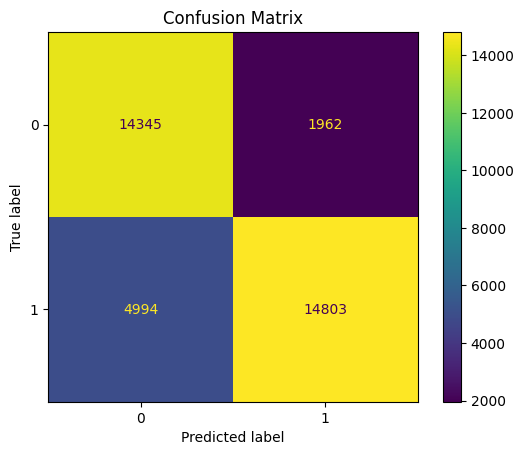

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("Confusion Matrix")
plt.show()


## Confusion Matrix Interpretation

The confusion matrix shows the number of correct and incorrect predictions made by the model.

- The model correctly predicted 14,353 on-time deliveries.
- It also correctly identified 15,078 late deliveries.

Some errors occur where the model predicts a delivery will be on time when it is actually late (4,719 cases), and vice versa (1,954 cases).

Overall, the model performs well with an accuracy of approximately 81%, indicating that it is effective at identifying delivery delays, although some misclassifications still exist.

# 10.Model Explainability (SHAP)

In [22]:
X_sample = X_test.sample(300, random_state=42)
explainer = shap.TreeExplainer(
    model,
    X_sample,
    feature_perturbation="tree_path_dependent", 
    approximate=True
)

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

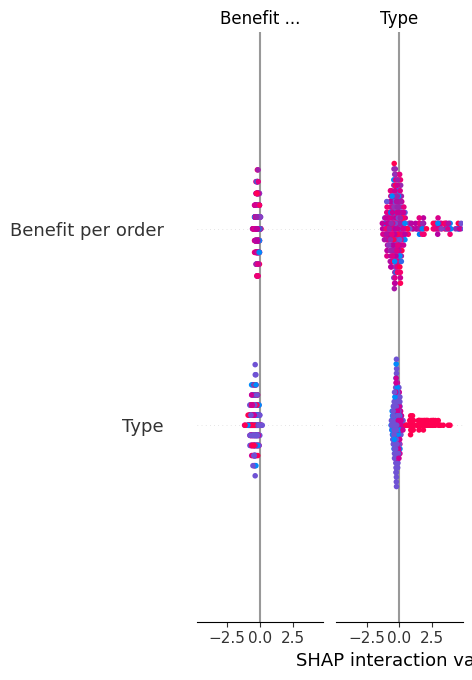

In [23]:
shap.summary_plot(shap_values, X_sample)

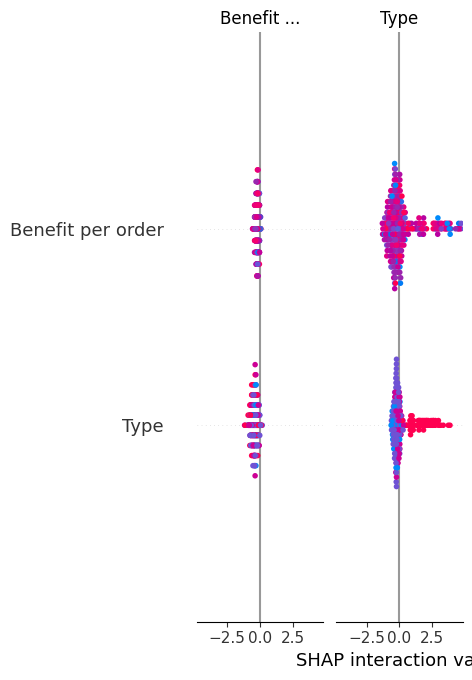

In [24]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

## Model Explainability using SHAP

To understand how the model makes predictions, SHAP (SHapley Additive Explanations) is used. SHAP helps explain the impact of each feature on the model’s output.

A sample of the test data was used to reduce computation time while still providing meaningful insights.

From the SHAP summary plot, features such as "Type" and "Benefit per order" have a strong influence on the prediction of delivery delays. The position of the points shows whether a feature increases or decreases the likelihood of a delay.

The bar plot also confirms the most important features overall, highlighting which variables contribute the most to the model’s decisions.

Overall, SHAP provides a clear and detailed understanding of how different features affect delivery delay predictions.

# 11.Bias and Fairness Analysis

In [25]:
original_df = df.copy()

In [26]:
# Create a copy of test data
bias_df = X_test.copy()

# Add actual and predicted values
bias_df['Actual'] = y_test
bias_df['Predicted'] = model.predict(X_test)

# Add Shipping Mode from original dataset
bias_df['Shipping Mode'] = original_df.loc[X_test.index, 'Shipping Mode']

# Group by Shipping Mode
bias_results = bias_df.groupby('Shipping Mode')[['Actual', 'Predicted']].mean()

print(bias_results)

                 Actual  Predicted
Shipping Mode                     
0              0.947387   0.988248
1              0.462009   0.547170
2              0.764304   0.943353
3              0.383628   0.166682


<Axes: xlabel='Shipping Mode'>

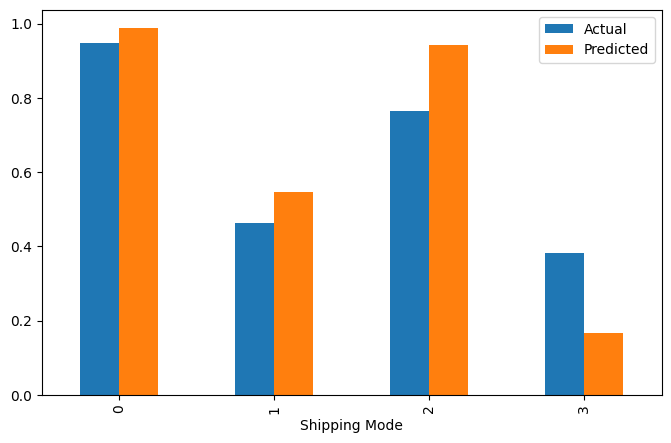

In [27]:
bias_results.plot(kind='bar', figsize=(8,5))

In [28]:
bias_df.groupby('Shipping Mode').size()

Shipping Mode
0     5531
1     1961
2     7026
3    21586
dtype: int64

The distribution of samples across shipping modes is not equal, which may also influence the results.

## Bias and Fairness Analysis

The bias analysis was conducted using the "Shipping Mode" feature, which represents different delivery service levels.

The results show that the predicted delay risk varies across different shipping modes. For example, Shipping Mode 2 has higher predicted delay probabilities compared to others, while Shipping Mode 3 shows lower predicted values.

This suggests that the model may treat different shipping modes differently. However, these differences could be due to actual patterns in the data rather than unfair bias.

Additionally, the distribution of samples across shipping modes is not equal, which may also influence the results.

Overall, while there are variations across groups, there is no strong evidence of severe bias, but the results should be interpreted carefully.

## Key Business Insights

Based on the analysis and machine learning results, several factors influence delivery delays:

- Orders with longer shipping times are more likely to be delayed.  
- Certain regions experience higher delays, possibly due to logistics and transportation challenges.  
- Larger order quantities may increase shipment complexity, leading to delays.  

These insights can help companies improve logistics planning, optimize shipping strategies, and allocate resources more effectively to reduce delivery delays.

## Conclusion

In this project, a machine learning model was developed to predict the risk of delivery delays using supply chain data. The Random Forest classifier achieved an accuracy of approximately 81%, showing good performance in identifying both delayed and on-time deliveries.

Exploratory data analysis revealed important patterns related to shipping methods, regional performance, and order characteristics. Feature engineering and preprocessing steps helped improve the model’s predictive ability.

SHAP analysis provided deeper insights into how different features influence the model’s predictions, highlighting the importance of variables such as shipping type and order-related factors.

The bias analysis showed some variation across different shipping modes, but no strong evidence of severe bias was found. However, differences in data distribution should be considered when interpreting the results.

Overall, this project demonstrates how machine learning can be applied to supply chain data to identify potential delivery delays and support better decision-making. These insights can help businesses optimize logistics, improve customer satisfaction, and reduce operational inefficiencies.

Future work could include testing more advanced models and incorporating additional real-time data to further improve prediction accuracy.

In [29]:
df.to_csv("cleaned_data.csv", index=False)

# 12. Pipeline and Model Saving

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# Separate columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Full pipeline
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Train
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [31]:
import joblib

joblib.dump(pipeline, 'model.joblib')

['model.joblib']

In [32]:
model = joblib.load('model.joblib')

model.predict(X_test.head())

In [34]:
import joblib
import pandas as pd

# Load model
def load_model():
    return joblib.load('model.joblib')

# Prediction function
def predict(data):
    model = load_model()
    return model.predict(data)

sample = X_test.head()
predictions = predict(sample)

print(predictions)

[0 1 0 1 0]
